Carga de datos

In [ ]:
import pandas as pd
from darts.models import MultivariateModel

from darts import TimeSeries
from darts.models import RNNModel


from darts.metrics import mae, rmse

path = "./df_train.csv"
datos = pd.read_csv(path)

datos["Datetime"] = pd.to_datetime(datos["Datetime"])

from darts import TimeSeries






## Separacion train y test

In [ ]:

split_train_end = "2016-06-30"
split_test_start = "2016-07-01"
split_test_end = "2017-07-31"

datos_train = datos[datos["Datetime"] <= split_train_end].copy()

datos_test = datos[
    (datos["Datetime"] >= split_test_start) &
    (datos["Datetime"] <= split_test_end)].copy()


series_train = []
series_test = []
for col in datos_train.columns:
    if col not in ["ID", "Datetime"]:

        df = datos_train[["Datetime", col]].dropna()

        ts = TimeSeries.from_dataframe(
            df,
            time_col="Datetime",
            value_cols=col
        )

        series_train.append(ts)


for col in datos_test.columns:
    if col not in ["ID", "Datetime"]:

        df = datos_test[["Datetime", col]].dropna()

        ts = TimeSeries.from_dataframe(
            df,
            time_col="Datetime",
            value_cols=col
        )

        series_test.append(ts)

### Entrenamiento con Darts - 
RNNMoldel - LSTM  (RNN = Red Neuronal Recurrente, LSTM = Long Short Term Memory)

In [ ]:


model_LSTM = RNNModel(
    model="LSTM",          # también puede ser "GRU" o "RNN"
    input_chunk_length=365,
    training_length=365,
    hidden_dim=64,
    n_rnn_layers=2,
    dropout=0.2,
    batch_size=64,
    n_epochs=50,
    random_state=42,
)

model_LSTM.fit(series_train)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 50.4 K | train
6 | V               | Linear           | 65     | train
-------------------------------------------------------------
50.5 K    Trainable params
0         Non-trainable params
50.5 K    Total params
0.404     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

d:\Curso_AA_Series_temporales\ts\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
d:\Curso_AA_Series_temporales\ts\Lib\site-packages\pytorch_lightning\utilities\data.py:106: Total length of `list` across ranks is zero. Please make sure this was your intention.
d:\Curso_AA_Series_temporales\ts\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training: |          | 0/? [00:00<?, ?it/s]

## Predicción

In [ ]:
predicciones_LSTM = model_LSTM.predict(
    n=len(series_test[0]),   # número de pasos a predecir
    series=series_train      # comienza desde el final del train
)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
d:\Curso_AA_Series_temporales\ts\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
d:\Curso_AA_Series_temporales\ts\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Predicting: |          | 0/? [00:00<?, ?it/s]

In [106]:
for i in range(8):
    print(i)
    print(predicciones_LSTM[i].head())
    print(predicciones_LSTM[i].tail())

0
                     A
Datetime              
2016-07-01  325.041523
2016-07-02  325.041522
2016-07-03  325.041522
2016-07-04  325.041522
2016-07-05  325.041522

shape: (5, 1, 1), freq: D, size: 40.00 B
                     A
Datetime              
2017-07-27  325.041522
2017-07-28  325.041522
2017-07-29  325.041522
2017-07-30  325.041522
2017-07-31  325.041522

shape: (5, 1, 1), freq: D, size: 40.00 B
1
                     B
Datetime              
2016-07-01  325.041523
2016-07-02  325.041522
2016-07-03  325.041522
2016-07-04  325.041522
2016-07-05  325.041522

shape: (5, 1, 1), freq: D, size: 40.00 B
                     B
Datetime              
2017-07-27  325.041522
2017-07-28  325.041522
2017-07-29  325.041522
2017-07-30  325.041522
2017-07-31  325.041522

shape: (5, 1, 1), freq: D, size: 40.00 B
2
                     C
Datetime              
2016-07-01  325.041523
2016-07-02  325.041522
2016-07-03  325.041522
2016-07-04  325.041522
2016-07-05  325.041522

shape: (5, 1, 1), fr

## Metricas

In [86]:
from darts.metrics import rmse

for i in range(len(series_train)):
    print(rmse(series_test[i], predicciones_LSTM[i]))

355003.87929708714
277705.5284338616
48773.414549633075
75998.95380258381
274683.80330806447
38538.19769951618
34825.70353406967
188837.7329913984


In [87]:
for i in range(len(series_test)):
    error = rmse(series_test[i], predicciones_LSTM[i])
    media = series_test[i].values().mean()
    print(f"Serie {i}: RMSE={error:.0f}, RMSE/Media={100*error/media:.2f}%")

Serie 0: RMSE=355004, RMSE/Media=100.66%
Serie 1: RMSE=277706, RMSE/Media=101.21%
Serie 2: RMSE=48773, RMSE/Media=100.41%
Serie 3: RMSE=75999, RMSE/Media=100.70%
Serie 4: RMSE=274684, RMSE/Media=101.28%
Serie 5: RMSE=38538, RMSE/Media=100.31%
Serie 6: RMSE=34826, RMSE/Media=100.56%
Serie 7: RMSE=188838, RMSE/Media=100.74%


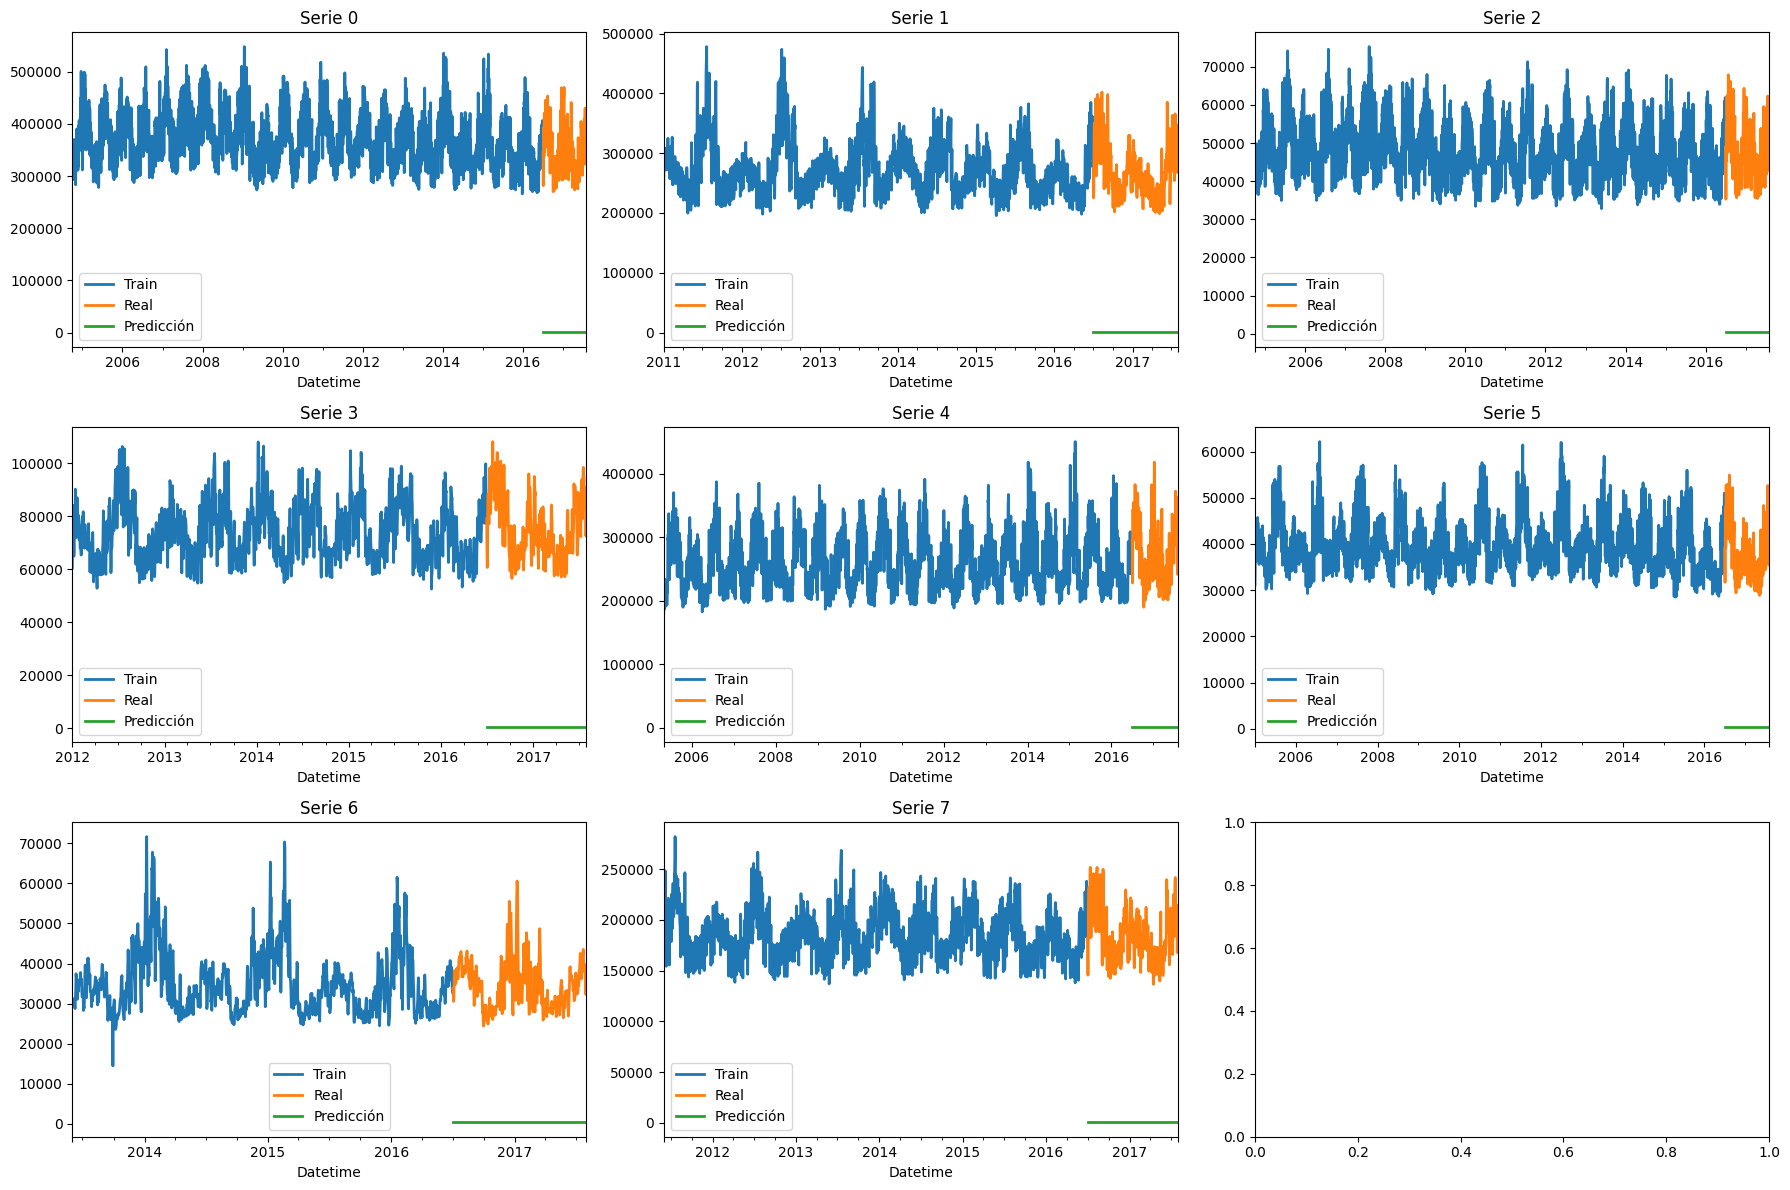

In [97]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, i in zip(axes, range(0, 8)):
    series_train[i].plot(ax=ax, label="Train")
    series_test[i].plot(ax=ax, label="Real")
    predicciones_LSTM[i].plot(ax=ax, label="Predicción")

    ax.set_title(f"Serie {i}")
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
print(predicciones_LSTM[0].head())

import pandas as pd

# DataFrame de salida
df_pred = pd.DataFrame()

# Columna ID
n = len(predicciones_LSTM[0])
df_pred["ID"] = range(n)

# Agregar una columna por cada serie
for ts in predicciones_LSTM:
    nombre = ts.components[0]          # A, B, C, ...
    df_pred[nombre] = ts.values().flatten()

# Guardar
df_pred.to_csv("predicciones_LSTM.csv", index=False)

print(df_pred.head())

                        A
Datetime                 
2016-07-01  328245.403702
2016-07-02  346969.282929
2016-07-03  314324.712913
2016-07-04  289150.196341
2016-07-05  329246.684859

shape: (5, 1, 1), freq: D, size: 40.00 B
   ID              A              B             C             D  \
0   0  328245.403702  266265.771144  46192.112784  73761.384012   
1   1  346969.282929  283382.790854  48250.470308  79260.368698   
2   2  314324.712913  260329.874532  43160.250051  73380.644071   
3   3  289150.196341  241571.023392  40378.499922  66123.406108   
4   4  329246.684859  279163.162688  46685.949083  74437.516415   

               E             F             G              H  
0  261351.545207  37544.329248  30643.820618  175043.919874  
1  283041.373524  40062.923986  35014.523165  184213.472408  
2  263537.056696  37372.481906  32310.666737  165738.152029  
3  232543.592481  32796.537377  29355.907453  149921.678720  
4  256679.012362  38249.189766  31424.362051  176313.839252  


In [62]:
import pandas as pd
import holidays

from darts import TimeSeries, concatenate
from darts.utils.timeseries_generation import datetime_attribute_timeseries

us_holidays = holidays.US()

future_covariates = []

for train_ts, test_ts in zip(series_train, series_test):

    # Índice temporal completo (train + test)
    full_index = train_ts.time_index.union(test_ts.time_index)

    dummy = pd.DataFrame(index=full_index)
    dummy["t"] = 0

    ts_full = TimeSeries.from_dataframe(dummy, value_cols="t")

    # Covariables de calendario
    dow = datetime_attribute_timeseries(
        ts_full,
        attribute="day_of_week",
        one_hot=False
    )

    dom = datetime_attribute_timeseries(
        ts_full,
        attribute="day",
        one_hot=False
    )

    doy = datetime_attribute_timeseries(
        ts_full,
        attribute="day_of_year",
        one_hot=False
    )

    month = datetime_attribute_timeseries(
        ts_full,
        attribute="month",
        one_hot=False
    )

    # Feriados de EE.UU.
    holiday_df = pd.DataFrame(index=full_index)
    holiday_df["holiday"] = holiday_df.index.map(
        lambda d: int(d in us_holidays)
    )

    holiday = TimeSeries.from_dataframe(
        holiday_df,
        value_cols="holiday"
    )

    cov = concatenate(
        [dow, dom, doy, month, holiday],
        axis=1
    )

    future_covariates.append(cov)

In [ ]:

from darts.models import TiDEModel

model_2 = TiDEModel(
    input_chunk_length=365,
    output_chunk_length=365,
    hidden_size=128,
    decoder_output_dim=16,
    temporal_decoder_hidden=64,
    num_encoder_layers=2,
    num_decoder_layers=2,
    dropout=0.1,
    batch_size=32,
    n_epochs=6,
    random_state=42,
)

from darts.dataprocessing.transformers import Scaler

scaler = Scaler()
cov_scaler = Scaler()

series_train_scaled = scaler.fit_transform(series_train)
series_test_scaled = scaler.transform(series_test)
future_covariates_scaled = cov_scaler.fit_transform(future_covariates)

model_2.fit(
    series_train_scaled,
    future_covariates=future_covariates_scaled
)

predicciones_2 = model_2.predict(
    n=365,
    series=series_train_scaled,
    future_covariates=future_covariates_scaled
)

pred_2 = scaler.inverse_transform(predicciones_2)



GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name                  | Type             | Params | Mode 
-------------------------------------------------------------------
0 | criterion             | MSELoss          | 0      | train
1 | train_criterion       | MSELoss          | 0      | train
2 | val_criterion         | MSELoss          | 0      | train
3 | train_metrics         | MetricCollection | 0      | train
4 | val_metrics           | MetricCollection | 0      | train
5 | future_cov_projection | _ResidualBlock   | 1.3 K  | train
6 | encoders              | Sequential       | 907 K  | train
7 | decoders              | Sequential       | 1.6 M  | train
8 | temporal_decoder      | _ResidualBlock   | 1.4 K  | train
9 | lookback_skip         | Linear           | 133 K  | train
-------------------------------------------------------------------
2.6 M     Trainable params
0         Non-trainable params
2.6 M     Total params
20.931    Total estimated

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

d:\Curso_AA_Series_temporales\ts\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
d:\Curso_AA_Series_temporales\ts\Lib\site-packages\pytorch_lightning\utilities\data.py:106: Total length of `list` across ranks is zero. Please make sure this was your intention.
d:\Curso_AA_Series_temporales\ts\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=6` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

In [69]:
print(pred.__class__)
print(pred[0])
print(series_train[0])

<class 'list'>
                       A
Datetime                
2016-07-01  9.272171e+10
2016-07-02  9.801076e+10
2016-07-03  8.878945e+10
2016-07-04  8.167826e+10
2016-07-05  9.300455e+10
...                  ...
2017-06-26  9.615976e+10
2017-06-27  9.013169e+10
2017-06-28  9.399944e+10
2017-06-29  9.825080e+10
2017-06-30  8.415700e+10

shape: (365, 1, 1), freq: D, size: 2.85 KB
                   A
Datetime            
2004-10-01  328544.0
2004-10-02  311997.0
2004-10-03  293450.0
2004-10-04  343417.0
2004-10-05  346553.0
...              ...
2016-06-26  365553.0
2016-06-27  406553.0
2016-06-28  380789.0
2016-06-29  352009.0
2016-06-30  350655.0

shape: (4291, 1, 1), freq: D, size: 33.52 KB


In [ ]:
for i in range(len(series_train)):
    print(rmse(series_test[i], pred_2[i]))

84249725942.13173
65321156434.950714
1727762619.4753606
3511196095.983915
60418950064.49381
1094051803.5459254
1675483973.3061433
22692130383.53017


In [71]:
for i in range(len(series_test)):
    error = rmse(series_test[i], pred[i])
    media = series_test[i].values().mean()
    print(f"Serie {i}: RMSE={error:.0f}, RMSE/Media={100*error/media:.2f}%")

Serie 0: RMSE=84249725942, RMSE/Media=23887939.50%
Serie 1: RMSE=65321156435, RMSE/Media=23805745.16%
Serie 2: RMSE=1727762619, RMSE/Media=3556868.14%
Serie 3: RMSE=3511196096, RMSE/Media=4652304.39%
Serie 4: RMSE=60418950064, RMSE/Media=22277375.33%
Serie 5: RMSE=1094051804, RMSE/Media=2847535.62%
Serie 6: RMSE=1675483973, RMSE/Media=4837770.44%
Serie 7: RMSE=22692130384, RMSE/Media=12106164.16%


In [77]:
print(pred[0].head())

                       A
Datetime                
2016-07-01  9.272171e+10
2016-07-02  9.801076e+10
2016-07-03  8.878945e+10
2016-07-04  8.167826e+10
2016-07-05  9.300455e+10

shape: (5, 1, 1), freq: D, size: 40.00 B


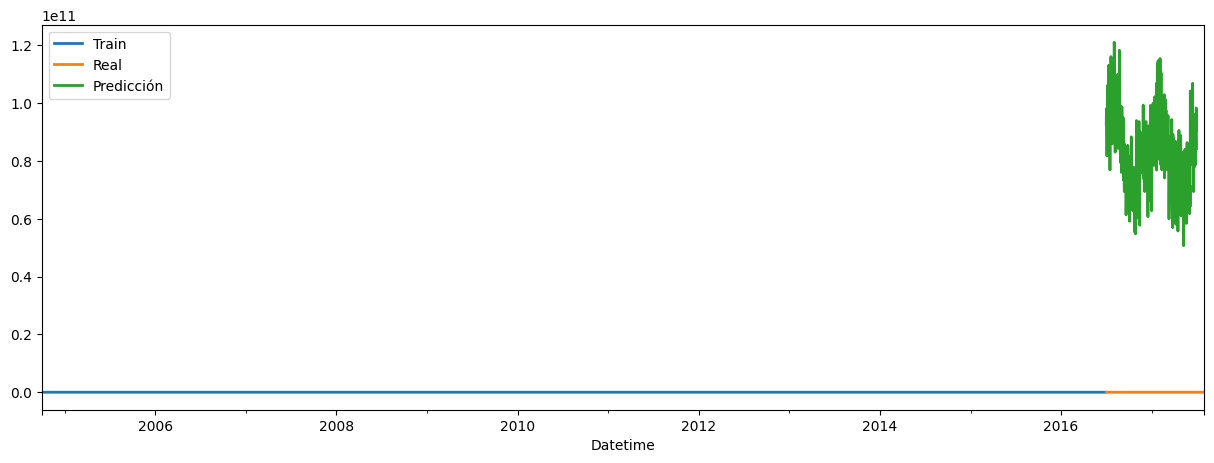

In [76]:
import matplotlib.pyplot as plt

i = 0

plt.figure(figsize=(15,5))
series_train[i].plot(label="Train")
series_test[i].plot(label="Real")
pred[i].plot(label="Predicción")

plt.legend()
plt.show()